In [1]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import os, json
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pycocotools.coco import COCO

In [31]:
# ── 1. Paths ──────────────────────────────────────────────────────────────────
DATA_RAW = r'D:\Lightweight_Object_Detection_Robustness\data\raw'
ANN_FILE = DATA_RAW + r'\annotations_trainval2017\annotations\instances_val2017.json'
IMG_DIR  = DATA_RAW + r'\val2017\val2017'

coco = COCO(ANN_FILE)
print(COCO)
print(IMG_DIR)
print(ANN_FILE)
# print('COCO loaded')

loading annotations into memory...
Done (t=0.84s)
creating index...
index created!
<class 'pycocotools.coco.COCO'>
D:\Lightweight_Object_Detection_Robustness\data\raw\val2017\val2017
D:\Lightweight_Object_Detection_Robustness\data\raw\annotations_trainval2017\annotations\instances_val2017.json


In [34]:
cats = coco.loadCats(coco.getCatIds())
for cat in cats:
    print(cat['id'], cat['name'])

1 person
2 bicycle
3 car
4 motorcycle
5 airplane
6 bus
7 train
8 truck
9 boat
10 traffic light
11 fire hydrant
13 stop sign
14 parking meter
15 bench
16 bird
17 cat
18 dog
19 horse
20 sheep
21 cow
22 elephant
23 bear
24 zebra
25 giraffe
27 backpack
28 umbrella
31 handbag
32 tie
33 suitcase
34 frisbee
35 skis
36 snowboard
37 sports ball
38 kite
39 baseball bat
40 baseball glove
41 skateboard
42 surfboard
43 tennis racket
44 bottle
46 wine glass
47 cup
48 fork
49 knife
50 spoon
51 bowl
52 banana
53 apple
54 sandwich
55 orange
56 broccoli
57 carrot
58 hot dog
59 pizza
60 donut
61 cake
62 chair
63 couch
64 potted plant
65 bed
67 dining table
70 toilet
72 tv
73 laptop
74 mouse
75 remote
76 keyboard
77 cell phone
78 microwave
79 oven
80 toaster
81 sink
82 refrigerator
84 book
85 clock
86 vase
87 scissors
88 teddy bear
89 hair drier
90 toothbrush


In [3]:
# ── 2. Traffic Classes Only ───────────────────────────────────────────────────
TRAFFIC = {1:'person', 2:'bicycle', 3:'car', 4:'motorcycle',
           6:'bus', 8:'truck', 10:'traffic light', 13:'stop sign'}

traffic_img_ids = set()
for cat_id in TRAFFIC:
    traffic_img_ids.update(coco.getImgIds(catIds=[cat_id]))
traffic_img_ids = sorted(traffic_img_ids)

print(f'Total val2017 images   : 5000')
print(f'Traffic-relevant images: {len(traffic_img_ids)}')

Total val2017 images   : 5000
Traffic-relevant images: 3028


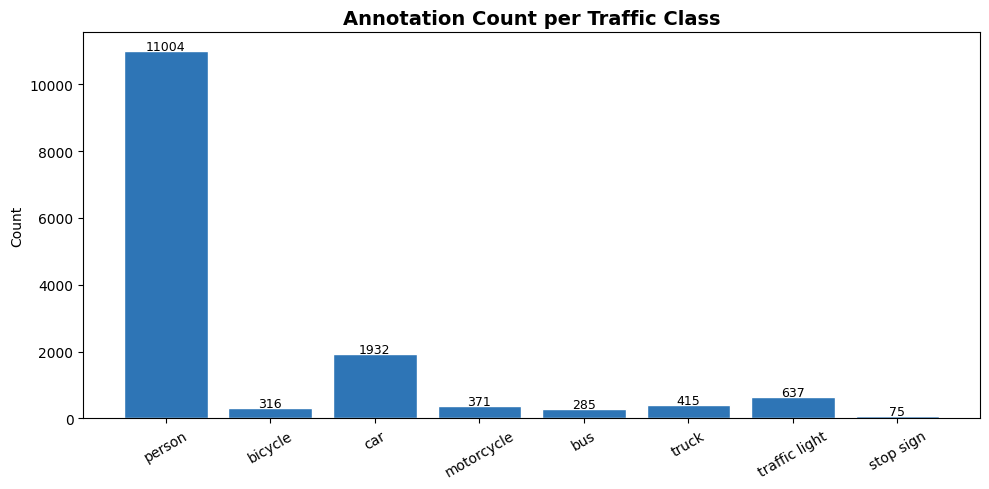

In [4]:
# ── 3. Annotation Counts per Class ────────────────────────────────────────────
class_counts = Counter()
for cat_id in TRAFFIC:
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    class_counts[TRAFFIC[cat_id]] = len(ann_ids)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(class_counts.keys(), class_counts.values(), color='#2E75B6', edgecolor='white')
ax.set_title('Annotation Count per Traffic Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(class_counts.items()):
    ax.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

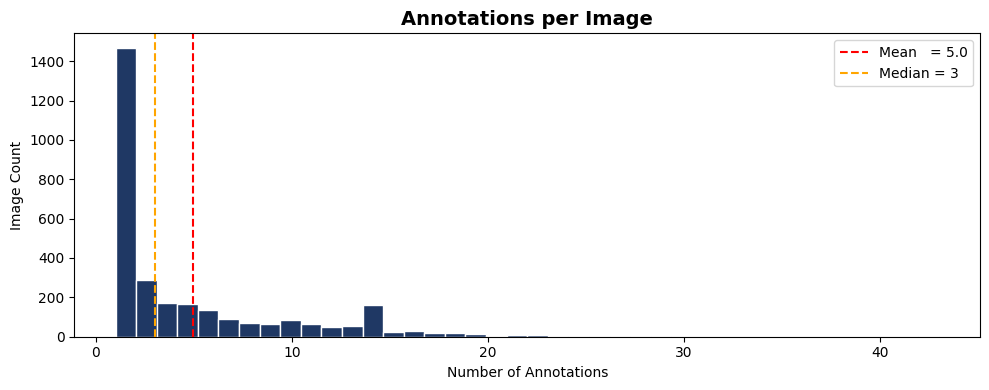

count    3028.000000
mean        4.965324
std         5.232593
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max        43.000000
dtype: float64


In [5]:
# ── 4. Annotations per Image Distribution ────────────────────────────────────
ann_counts = []
for img_id in traffic_img_ids:
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=list(TRAFFIC.keys()))
    ann_counts.append(len(ann_ids))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ann_counts, bins=40, color='#1F3864', edgecolor='white')
ax.axvline(np.mean(ann_counts),   color='red',    linestyle='--', label=f'Mean   = {np.mean(ann_counts):.1f}')
ax.axvline(np.median(ann_counts), color='orange', linestyle='--', label=f'Median = {np.median(ann_counts):.0f}')
ax.set_title('Annotations per Image', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Annotations')
ax.set_ylabel('Image Count')
ax.legend()
plt.tight_layout()
plt.show()

print(pd.Series(ann_counts).describe())

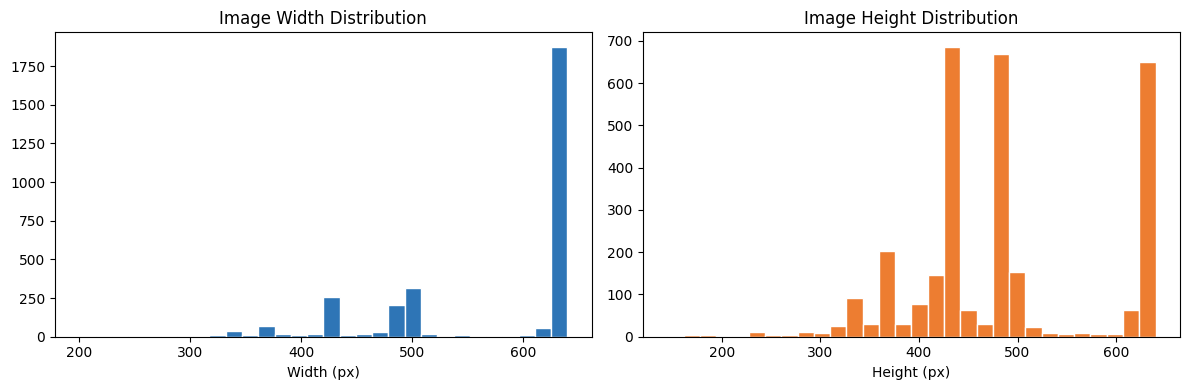

Width  — min:200  max:640  avg:572
Height — min:145  max:640  avg:483


In [6]:
# ── 5. Image Size Distribution ───────────────────────────────────────────────
widths, heights = [], []
for img_id in traffic_img_ids:
    info = coco.loadImgs(img_id)[0]
    widths.append(info['width'])
    heights.append(info['height'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='#2E75B6', edgecolor='white')
axes[0].set_title('Image Width Distribution');  axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=30, color='#ED7D31', edgecolor='white')
axes[1].set_title('Image Height Distribution'); axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.show()

print(f'Width  — min:{min(widths)}  max:{max(widths)}  avg:{np.mean(widths):.0f}')
print(f'Height — min:{min(heights)}  max:{max(heights)}  avg:{np.mean(heights):.0f}')

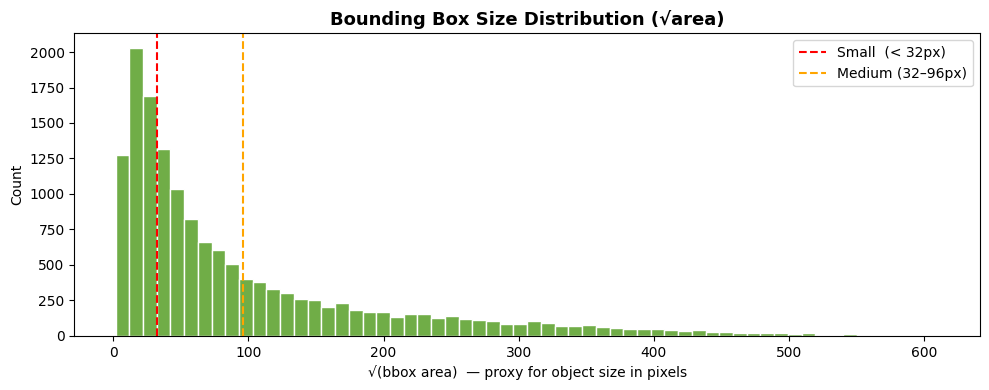

Small  (< 32px)  : 4986  (33.2%)
Medium (32–96px) : 5087 (33.8%)
Large  (> 96px)  : 4962  (33.0%)


In [7]:
# ── 6. Bounding Box Size Distribution ────────────────────────────────────────
bbox_areas = []
for cat_id in TRAFFIC:
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    anns    = coco.loadAnns(ann_ids)
    for ann in anns:
        w, h = ann['bbox'][2], ann['bbox'][3]
        bbox_areas.append(w * h)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.sqrt(bbox_areas), bins=60, color='#70AD47', edgecolor='white')
ax.set_title('Bounding Box Size Distribution (√area)', fontsize=13, fontweight='bold')
ax.set_xlabel('√(bbox area)  — proxy for object size in pixels')
ax.set_ylabel('Count')
ax.axvline(32,  color='red',    linestyle='--', label='Small  (< 32px)')
ax.axvline(96,  color='orange', linestyle='--', label='Medium (32–96px)')
ax.legend()
plt.tight_layout()
plt.show()

small  = sum(1 for a in bbox_areas if a < 32**2)
medium = sum(1 for a in bbox_areas if 32**2 <= a < 96**2)
large  = sum(1 for a in bbox_areas if a >= 96**2)
print(f'Small  (< 32px)  : {small}  ({100*small/len(bbox_areas):.1f}%)')
print(f'Medium (32–96px) : {medium} ({100*medium/len(bbox_areas):.1f}%)')
print(f'Large  (> 96px)  : {large}  ({100*large/len(bbox_areas):.1f}%)')

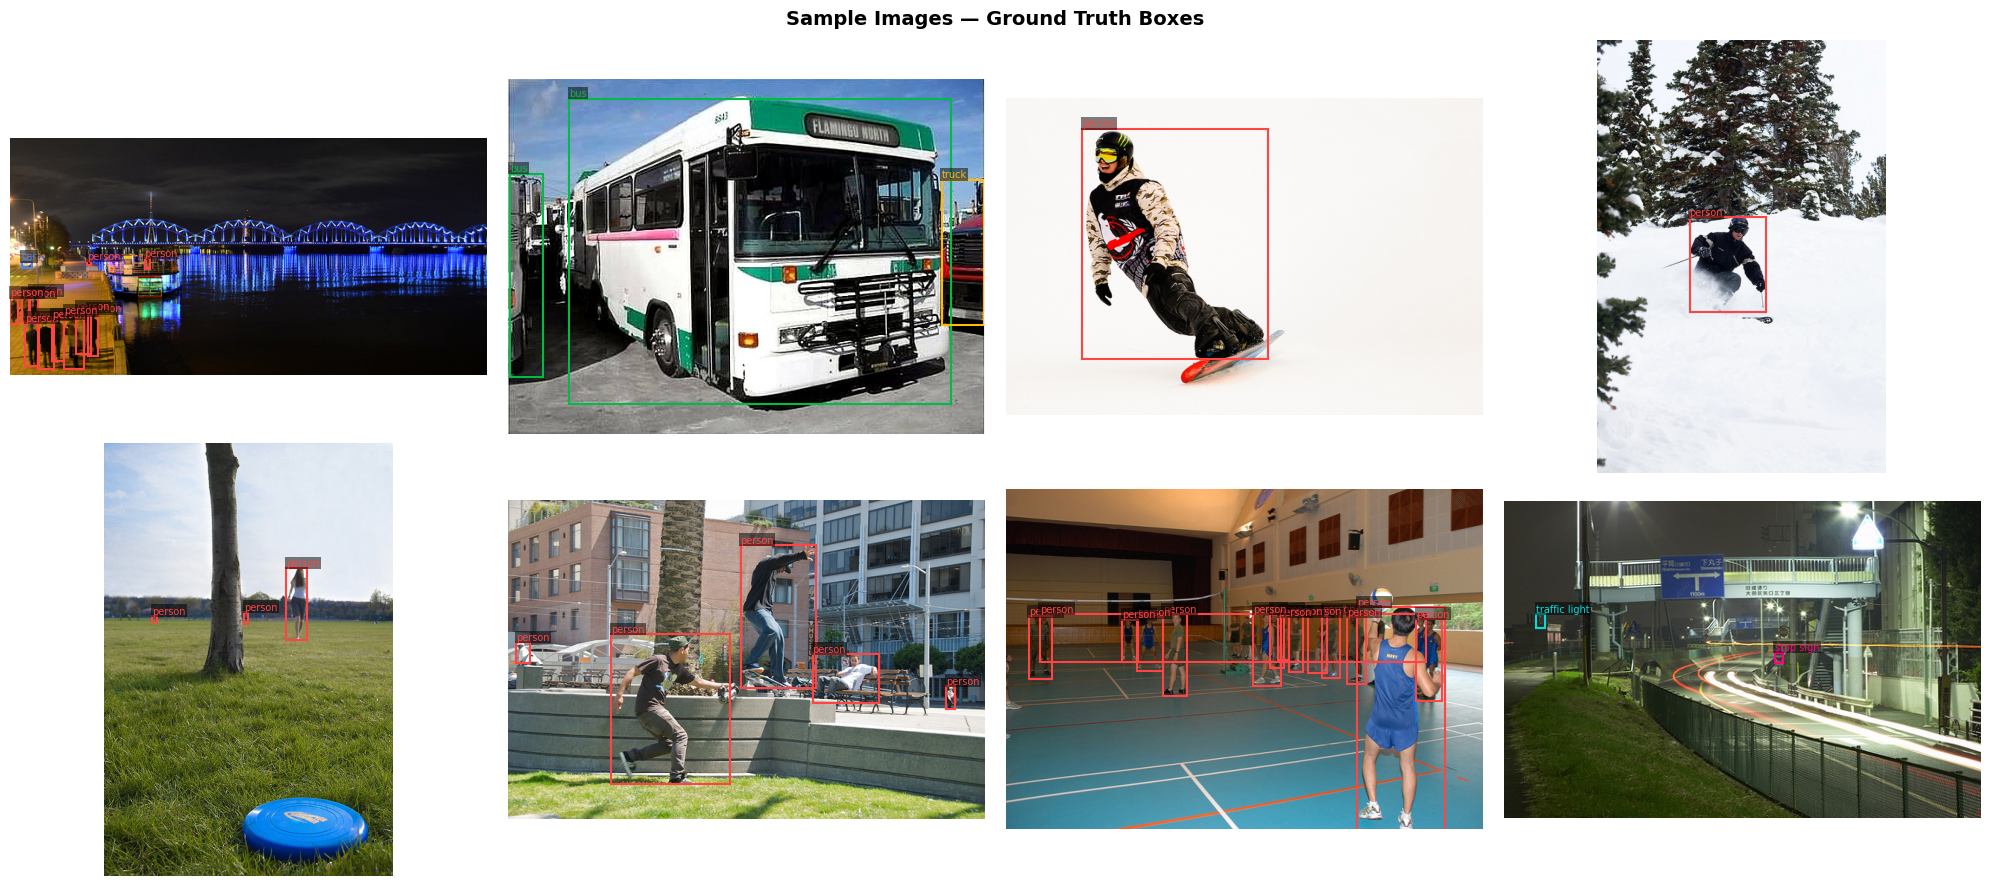

In [8]:
# ── 7. Sample Images with GT Boxes ───────────────────────────────────────────
COLORS = {'person':'#FF4444','bicycle':'#FF8800','car':'#4488FF',
          'motorcycle':'#AA44FF','bus':'#00BB44','truck':'#FFBB00',
          'traffic light':'#00DDDD','stop sign':'#FF0088'}

sample_ids = np.random.default_rng(42).choice(traffic_img_ids, 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Sample Images — Ground Truth Boxes', fontsize=14, fontweight='bold')

for ax, img_id in zip(axes.flatten(), sample_ids):
    info    = coco.loadImgs(int(img_id))[0]
    img     = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, info['file_name'])), cv2.COLOR_BGR2RGB)
    ann_ids = coco.getAnnIds(imgIds=int(img_id), catIds=list(TRAFFIC.keys()))
    anns    = coco.loadAnns(ann_ids)

    ax.imshow(img)
    for ann in anns:
        x, y, w, h = ann['bbox']
        name  = TRAFFIC[ann['category_id']]
        color = COLORS[name]
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor=color, facecolor='none'))
        ax.text(x, y - 3, name, fontsize=7, color=color,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))
    ax.axis('off')

plt.tight_layout()
plt.show()

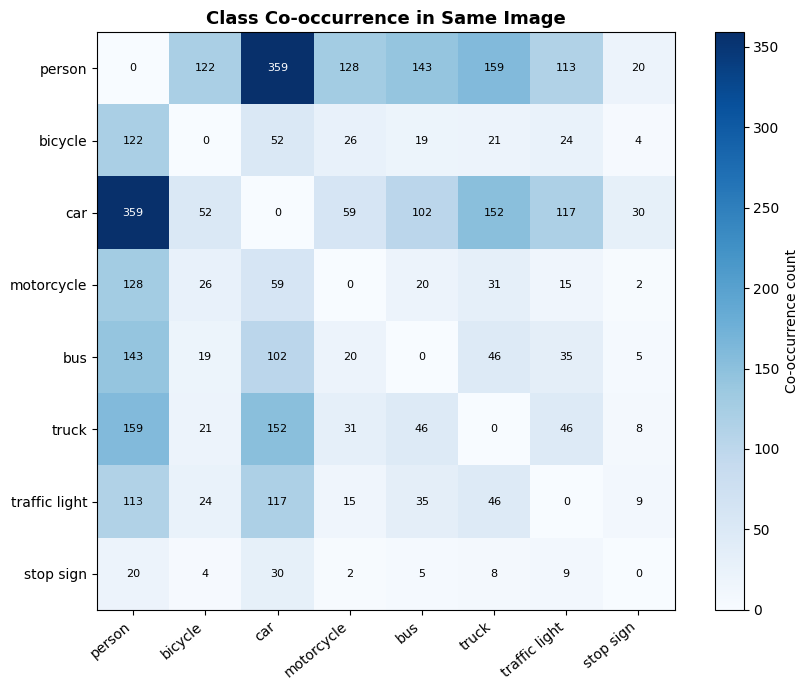

In [9]:
# ── 8. Co-occurrence Heatmap (which classes appear together) ──────────────────
import itertools

co_matrix = np.zeros((len(TRAFFIC), len(TRAFFIC)), dtype=int)
cat_ids   = list(TRAFFIC.keys())
cat_names = list(TRAFFIC.values())

for img_id in traffic_img_ids:
    ann_ids   = coco.getAnnIds(imgIds=img_id, catIds=cat_ids)
    anns      = coco.loadAnns(ann_ids)
    present   = set(ann['category_id'] for ann in anns)
    for a, b in itertools.combinations(present, 2):
        i, j = cat_ids.index(a), cat_ids.index(b)
        co_matrix[i][j] += 1
        co_matrix[j][i] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(co_matrix, cmap='Blues')
ax.set_xticks(range(len(cat_names))); ax.set_xticklabels(cat_names, rotation=40, ha='right')
ax.set_yticks(range(len(cat_names))); ax.set_yticklabels(cat_names)
ax.set_title('Class Co-occurrence in Same Image', fontsize=13, fontweight='bold')
for i in range(len(cat_names)):
    for j in range(len(cat_names)):
        ax.text(j, i, co_matrix[i, j], ha='center', va='center', fontsize=8,
                color='white' if co_matrix[i, j] > co_matrix.max() * 0.5 else 'black')
plt.colorbar(im, ax=ax, label='Co-occurrence count')
plt.tight_layout()
plt.show()